In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('/content/car_price_prediction_with_missing.csv')
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang


In [3]:
df.shape

(2500, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2250 non-null   float64
 1   Brand         2250 non-null   object 
 2   Year          2250 non-null   float64
 3   Engine Size   2250 non-null   float64
 4   Fuel Type     2250 non-null   object 
 5   Transmission  2250 non-null   object 
 6   Mileage       2250 non-null   float64
 7   Condition     2250 non-null   object 
 8   Price         2250 non-null   float64
 9   Model         2250 non-null   object 
dtypes: float64(5), object(5)
memory usage: 195.4+ KB


In [5]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000
mean,1251.243556,2011.577778,3.485467,150236.178222,52506.874391
std,725.637358,6.980468,1.427690,88150.746556,27232.417079
min,1.000000,2000.000000,1.000000,15.000000,5011.270000
25%,627.250000,2005.000000,2.300000,71178.500000,28985.052500
50%,1249.500000,2012.000000,3.450000,149762.000000,53485.240000
75%,1875.250000,2018.000000,4.700000,226299.000000,75560.340000
max,2500.000000,2023.000000,6.000000,299967.000000,99982.590000


In [6]:
df.isnull().sum()

,0
Car ID,250
Brand,250
Year,250
Engine Size,250
Fuel Type,250
Transmission,250
Mileage,250
Condition,250
Price,250
Model,250


In [7]:
df = df.dropna()

In [8]:
df.isnull().sum()

,0
Car ID,0
Brand,0
Year,0
Engine Size,0
Fuel Type,0
Transmission,0
Mileage,0
Condition,0
Price,0
Model,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(2250, 10)

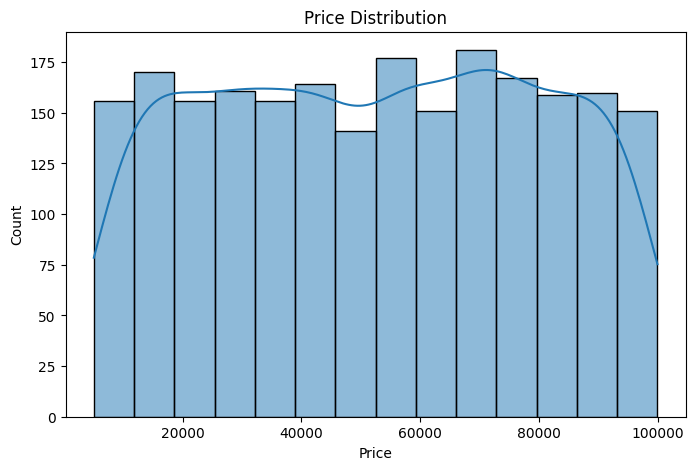

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

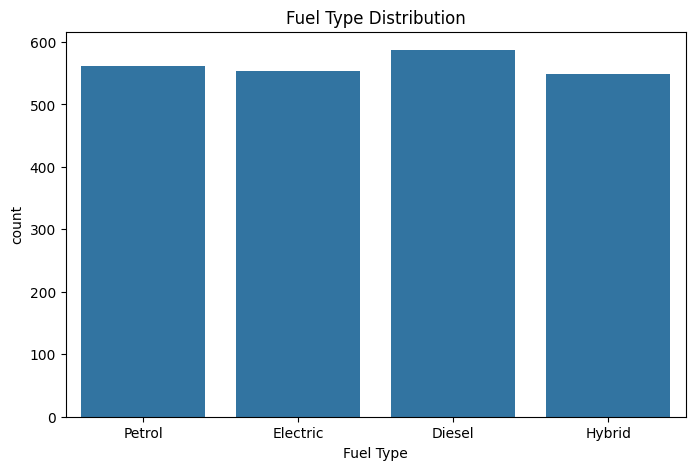

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Fuel Type', data=df)
plt.title('Fuel Type Distribution')
plt.show()

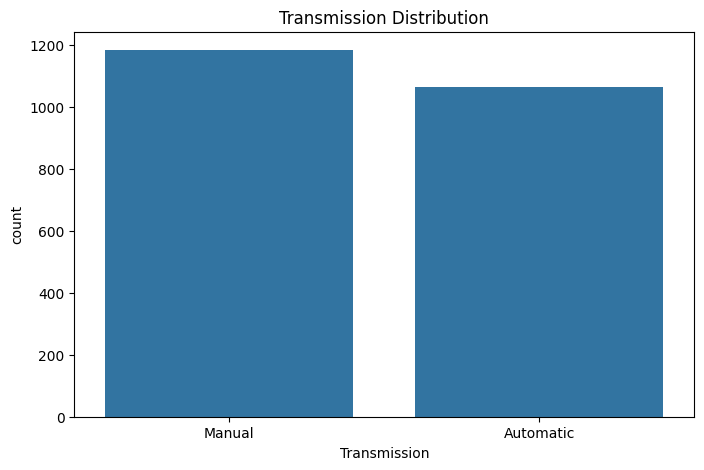

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='Transmission', data=df)
plt.title('Transmission Distribution')
plt.show()

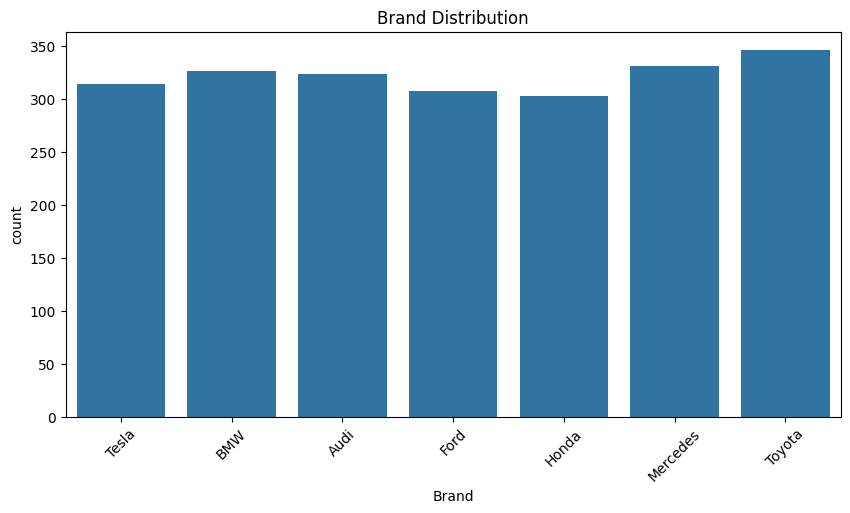

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(x='Brand', data=df)
plt.title('Brand Distribution')
plt.xticks(rotation=45)
plt.show()

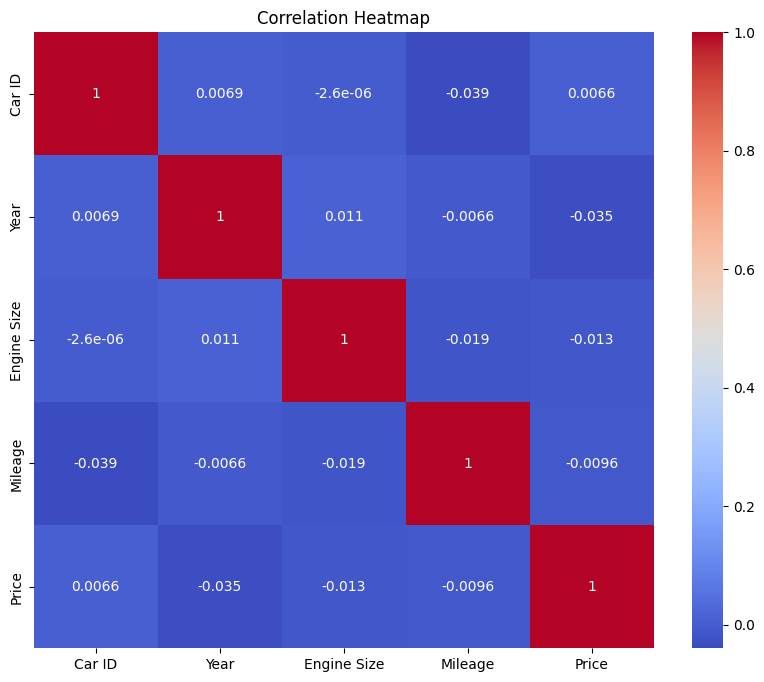

In [16]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Brand'] = le.fit_transform(df['Brand'])
df['Fuel Type'] = le.fit_transform(df['Fuel Type'])
df['Transmission'] = le.fit_transform(df['Transmission'])
df['Condition'] = le.fit_transform(df['Condition'])
df['Model'] = le.fit_transform(df['Model'])

In [18]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,5,2016.0,2.3,3,1,114832.0,1,26613.92,19
1,2.0,1,2018.0,4.4,1,1,143190.0,2,14679.61,1
2,3.0,0,2013.0,4.5,1,1,181601.0,1,44402.61,3
3,4.0,5,2011.0,4.1,0,0,68682.0,1,86374.33,20
4,5.0,2,2009.0,2.6,0,1,223009.0,0,73577.10,21


In [19]:
X = df.drop('Price', axis=1)
y = df['Price']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [22]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[61643.8185 55413.3813 62633.1802 53118.415  50816.3873 45255.4724
 43160.4563 57601.1103 58685.7765 49660.6428]


In [23]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 23713.840839555553
MSE : 781290410.8739247
RMSE : 27951.57260108856
R2 Score : -0.07281486174945306


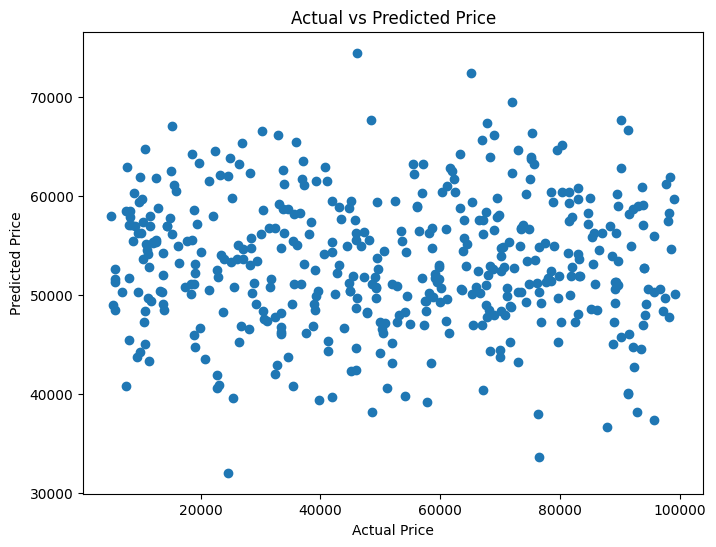

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

In [25]:
import pickle

pickle.dump(model, open('car_price_model.pkl', 'wb'))

In [26]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 23713.840839555553
MSE : 781290410.8739247
RMSE : 27951.57260108856
R2 Score : -0.07281486174945306
